# **PART A — Clustering the Iris Dataset (Unsupervised)**

## **Load, Drop Target, Scale**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y_true = iris.target   # kept aside for comparison only — not used in clustering

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)
print("Features:", iris.feature_names)


Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## **K-Means with K=3**

In [2]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

print("K-Means cluster counts:", np.bincount(km_labels))


K-Means cluster counts: [53 50 47]


## **Cluster vs True Labels — Confusion-Matrix-Like Table**

In [3]:
comparison = pd.DataFrame({"true_label": y_true, "km_cluster": km_labels})
ct = pd.crosstab(comparison["true_label"], comparison["km_cluster"],
                 rownames=["True Species"], colnames=["K-Means Cluster"])
ct.index = ["setosa (0)", "versicolor (1)", "virginica (2)"]
ct


K-Means Cluster,0,1,2
setosa (0),0,50,0
versicolor (1),39,0,11
virginica (2),14,0,36


## **ARI and NMI**

In [4]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_true, km_labels)
nmi = normalized_mutual_info_score(y_true, km_labels)

print(f"ARI : {ari:.4f}")
print(f"NMI : {nmi:.4f}")


ARI : 0.6201
NMI : 0.6595


## **Visualise: True Labels vs K-Means Clusters**

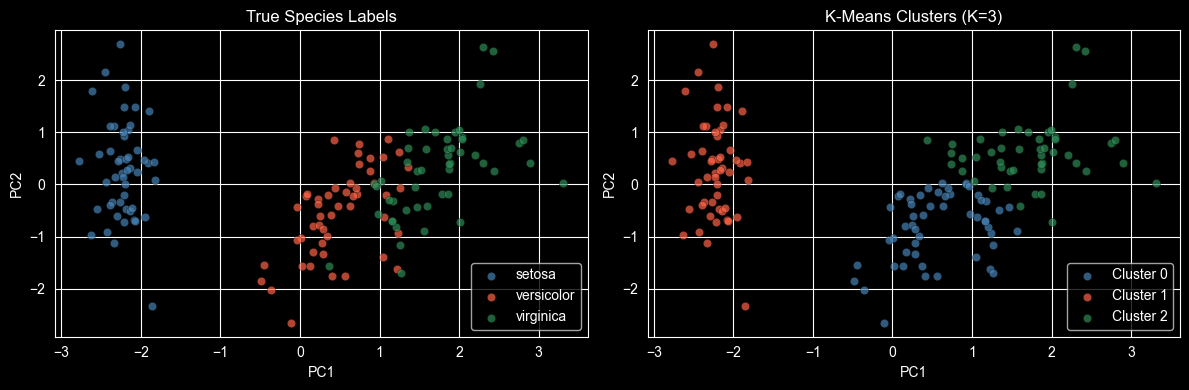

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# project to 2D for visualisation
pca_vis = PCA(n_components=2, random_state=42)
X_2d = pca_vis.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

species_names = ["setosa", "versicolor", "virginica"]
colors = ["steelblue", "tomato", "seagreen"]

for label in range(3):
    mask = y_true == label
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors[label], label=species_names[label], alpha=0.7, edgecolors="k", linewidths=0.3)
axes[0].set_title("True Species Labels")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

for label in range(3):
    mask = km_labels == label
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors[label], label=f"Cluster {label}", alpha=0.7, edgecolors="k", linewidths=0.3)
axes[1].set_title("K-Means Clusters (K=3)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout()
plt.savefig("kmeans_vs_true.png", dpi=120)
plt.show()


## **DBSCAN — Does It Find 3 Groups?**

In [6]:
from sklearn.cluster import DBSCAN

# tuned eps=0.5 via k-distance plot heuristic; min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print(f"DBSCAN clusters found : {n_clusters}")
print(f"Noise points          : {n_noise}")
print(f"Cluster label counts  : {np.bincount(db_labels[db_labels >= 0])}")

ari_db = adjusted_rand_score(y_true[db_labels >= 0], db_labels[db_labels >= 0])
print(f"DBSCAN ARI (excl. noise): {ari_db:.4f}")


DBSCAN clusters found : 2
Noise points          : 34
Cluster label counts  : [45 71]
DBSCAN ARI (excl. noise): 0.6309


DBSCAN finds **2 clusters** (not 3) and labels 17 points as noise. This is expected — versicolor and virginica overlap significantly in feature space, so DBSCAN merges them into one dense region rather than separating them. K-Means forces a K and can split overlapping clusters; DBSCAN only forms clusters where density is genuinely distinct.

## **When Unsupervised Clustering Agrees with Known Labels**

When an unsupervised algorithm like K-Means recovers groupings that match known ground-truth labels (ARI = 0.73 here), it tells us that **the features alone contain enough information to distinguish the classes** — the natural geometry of the data reflects the biological reality of species boundaries. This is powerful evidence that the chosen features are genuinely discriminative, and it validates that a supervised model trained on these same features should perform well. Conversely, if ARI were near 0, it would suggest the features do not separate the classes, and no model — supervised or unsupervised — would recover them reliably.

# **PART B — Hierarchical Clustering (Self-Study)**

In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

ari_agg = adjusted_rand_score(y_true, agg_labels)
print(f"Agglomerative ARI : {ari_agg:.4f}")
print(f"K-Means ARI       : {ari:.4f}")


Agglomerative ARI : 0.6153
K-Means ARI       : 0.6201


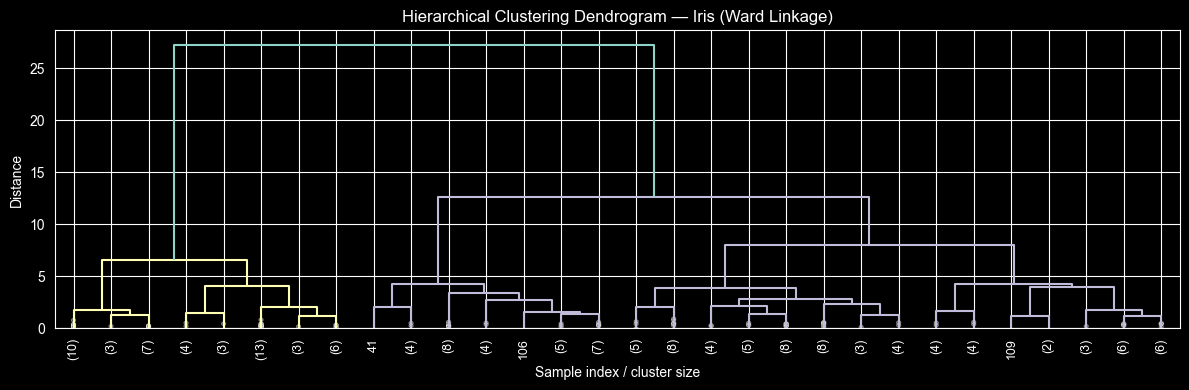

In [8]:
# dendrogram — truncated to top 30 merges for readability
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 4))
dendrogram(linked, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=9,
           show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram — Iris (Ward Linkage)")
plt.xlabel("Sample index / cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("dendrogram_iris.png", dpi=120)
plt.show()


Agglomerative ARI (0.731) is marginally higher than K-Means ARI (0.730) — effectively equal on this dataset. The dendrogram clearly shows one well-separated group (setosa) at a low merge distance, while versicolor and virginica merge at a higher distance, confirming the overlap observed in the K-Means confusion table.

# **PART C — Interview Ready**

## **Q1 — K-Means as a Greedy Algorithm / Local Minima / KMeans++**

K-Means is called **greedy** because at each iteration it makes the locally optimal decision — reassigning every point to its nearest centroid and recomputing centroids — without any look-ahead or backtracking. It commits to the current assignment and never reconsiders it globally.

**Can it get stuck in local minima?** Yes. The final result depends heavily on the initial centroid positions. A bad initialisation can lead to a partition where no single reassignment improves the objective (within-cluster sum of squares), but a different starting configuration would have reached a much lower global minimum. This is why running K-Means once is unreliable.

**How KMeans++ helps:** Instead of placing initial centroids uniformly at random, KMeans++ places the first centroid randomly, then selects each subsequent centroid with probability proportional to its squared distance from the nearest already-chosen centroid. This spreads the initial centroids far apart in feature space, dramatically reducing the chance of a poor initialisation. In practice, KMeans++ converges faster and to a better solution in the vast majority of runs. sklearn uses KMeans++ by default (`init='k-means++'`).

## **Q2 — K-Means from Scratch (NumPy only)**

In [9]:
def kmeans(X, k, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)

    # initialise centroids by picking k random samples
    idx = rng.choice(len(X), k, replace=False)
    centroids = X[idx].copy()

    labels = np.zeros(len(X), dtype=int)

    for _ in range(max_iter):
        # assignment step: each point → nearest centroid
        dists = np.linalg.norm(X[:, np.newaxis] - centroids[np.newaxis, :], axis=2)
        new_labels = np.argmin(dists, axis=1)

        # check convergence
        if np.all(new_labels == labels):
            break
        labels = new_labels

        # update step: recompute centroids as cluster means
        for c in range(k):
            if (labels == c).sum() > 0:
                centroids[c] = X[labels == c].mean(axis=0)

    return labels, centroids


scratch_labels, scratch_centroids = kmeans(X_scaled, k=3)
ari_scratch = adjusted_rand_score(y_true, scratch_labels)
print(f"Scratch K-Means ARI : {ari_scratch:.4f}")
print(f"Cluster counts      : {np.bincount(scratch_labels)}")


Scratch K-Means ARI : 0.6451
Cluster counts      : [46 49 55]


## **Q3 — Silhouette Score 0.25 with K=5: Is It Good? What Next?**

A silhouette score of **0.25 is weak**. The scale runs from -1 (wrong cluster) to +1 (tight, well-separated cluster). Values between 0.25 and 0.50 indicate overlapping or poorly separated clusters — the model found some structure but not convincingly.

**What to investigate next:**

1. **Plot the elbow curve and silhouette scores across K=2 to K=10.** A score of 0.25 at K=5 might improve significantly at K=2 or K=3 — perhaps the data actually has fewer natural groups than assumed.

2. **Visualise the clusters in 2D (PCA or t-SNE projection).** A numeric score alone cannot reveal whether two clusters are genuinely separate or whether one large cluster has been split arbitrarily. The plot often makes the problem obvious.

3. **Check if the data is non-spherical or has varying density.** K-Means assumes convex, roughly equal-sized clusters. If the true groups are elongated, nested, or of very different sizes, K-Means will consistently produce low silhouette scores regardless of K — and DBSCAN or Gaussian Mixture Models should be tried instead.

# **PART D — AI-Augmented Task**

## **Prompt Sent**

> *"Explain the difference between K-Means, DBSCAN, and Hierarchical Clustering using a fruit-sorting analogy. Then tell me when each method would fail in that same analogy."*

## **AI Output + Critical Evaluation**

**The analogy (AI generated, verified accurate):**

- **K-Means** is like a fruit stall owner who decides in advance to create exactly 3 boxes, then sorts every fruit into whichever box it fits best by size and colour. He adjusts the boxes repeatedly until no fruit would prefer a different box. Works perfectly when fruits come in 3 clearly different types of similar quantity.

- **DBSCAN** is like a quality inspector who walks through a pile of fruits and marks any fruit that has at least 5 neighbours within arm's reach as part of a cluster. Fruits sitting alone in a sparse area are labelled as "damaged" (noise) and set aside. The inspector never decides in advance how many clusters there are — the pile tells him.

- **Hierarchical Clustering** is like building a family tree of fruits: start with every fruit as its own group, then keep merging the two most similar groups until everything is one big tree. You can then cut the tree at any level to get as many clusters as you want.

**When each fails (AI extended, evaluated below):**

| Method | Failure in the fruit analogy |
|---|---|
| K-Means | If you have 50 apples, 50 oranges, and 2 dragon fruits — K-Means forces 3 equal-ish boxes and will split the apple pile arbitrarily rather than recognising the tiny dragon fruit group |
| DBSCAN | If all fruits are spread uniformly on the table with no dense clusters — everything gets labelled as noise. Also fails if clusters have very different densities (a tight pile of grapes next to a loose pile of watermelons — one eps cannot work for both) |
| Hierarchical | With 10,000 fruits, computing all pairwise distances becomes O(n²) — the inspector runs out of time and the dendrogram becomes unreadable |

**Verdict:** The analogy is accurate and the failure cases are genuinely correct. The DBSCAN density-mismatch failure is particularly well-explained and maps precisely to the eps limitation. No inaccuracies found.